# Biomedical Graph Neural Network (GNN) Tutorial
## Real-World Breast Cancer Classification via Graph Convolutional Networks

 > **Goal:** Build an end-to-end retrospective biomedical AI pipeline that (1) loads a real patient-derived benchmark dataset, (2) audits the cohort and label balance, (3) constructs a patient-similarity graph, (4) trains a Graph Convolutional Network (GCN), and (5) evaluates performance with clinically meaningful metrics.
 >
 > **For technical reviewers:** focus on dataset provenance, train/validation/test separation, no-leakage standardisation, graph construction choices, weighted loss, and malignant-case recall.
 >
 > **For nontechnical readers:** focus on the story of the notebook. Each row is one patient case, the graph links similar patients, and the model tries to avoid the most dangerous mistake: calling a malignant case benign.
 >
 > **Important realism note:** this notebook uses a real public biomedical dataset widely used in machine learning research, but it is still a retrospective research demonstration rather than a regulated clinical decision tool.

---

### Table of Contents
0. Beginner Primer and Notebook Roadmap
1. [Background, Provenance, and Clinical Framing](#background)
2. [Dataset and Graph Construction](#dataset)
3. [Graph Theory Primer](#theory)
4. [GCN Architecture and Training Logic](#gcn)
5. [Real-World Data Pipeline](#pipeline)
6. [Evaluation: PCA, Confusion Matrix, ROC, and Clinical Trade-offs](#evaluation)
7. [Applications and Extensions](#applications)
8. [Connection to QAOA](#qaoa)

---

### Why Graph Neural Networks for Biomedical Data?

Classical machine-learning models such as logistic regression, random forests, or MLPs usually treat each patient **independently**. A GNN adds one more layer of reasoning: *patients who look biologically similar may carry related diagnostic information*. That structure matters when disease patterns appear in neighborhoods rather than isolated records.

| Method | Captures inter-sample structure? | Handles irregular topology? |
|--------|----------------------------------|------------------------------|
| MLP    | x                                | -                            |
| CNN    | Only grid structure              | x                            |
| GNN    | yes, via message passing         | yes                          |

This is especially useful in:
- **Patient stratification** from electronic health records
- **Single-cell RNA-seq clustering** (cell-cell similarity graphs)
- **Drug-target interaction** prediction
- **Multi-omics integration** (gene expression + protein interaction networks)

In other words, this notebook is not only about classification accuracy. It is about showing how graph-based reasoning can turn biomedical tables into a structured learning problem that is closer to how scientific data behaves in practice.

## 0. Beginner Primer and Notebook Roadmap

This section is for readers who are completely new to the topic. You do **not** need prior training in graph theory, machine learning, linear algebra, or biomedical imaging to start. The goal is to make the rest of the notebook readable line by line.

### 0.1 What problem are we solving?

We have a table of patient measurements collected from breast tissue images. Each row is **one patient**, and each column is **one measured property** such as radius, texture, or smoothness.

We want a computer model to answer one question:

**Given these measurements, is this case more likely to be malignant or benign?**

That is a **classification** problem.

### 0.2 Plain-English dictionary

| Word | Meaning in this notebook |
|------|--------------------------|
| Data | Recorded information |
| Dataset | A collection of many examples |
| Sample | One example; here, one patient record |
| Feature | One measured input value; here, one biomedical measurement |
| Label | The answer we want to predict |
| Model | A mathematical rule that turns inputs into predictions |
| Training | Adjusting the model so it makes better predictions |
| Test set | Data kept aside to check whether the model works on unseen examples |
| Graph | A set of objects and the connections between them |
| Node | One object in the graph; here, one patient |
| Edge | A connection; here, two similar patients are linked |
| Neural network | A layered function with learnable parameters |
| Loss | A number that measures how wrong the model is |
| Accuracy | Fraction of predictions that are correct |
| Tensor | A data container used in PyTorch; in this notebook it behaves like a numeric array |

### 0.3 The minimum math needed

Only a small amount of math is needed to follow the notebook.

| Symbol | Meaning |
|--------|---------|
| $n$ | Number of samples (patients) |
| $d$ | Number of features per sample |
| $X$ | Feature matrix, shape $n \times d$ |
| $y$ | Label vector |
| $A$ | Adjacency matrix, which records graph connections |
| $W$ | Learnable weights inside the neural network |
| $H$ | Hidden representation learned by the network |
| $\mu$ | Mean (average) |
| $\sigma$ | Standard deviation (spread) |

A **vector** is just a list of numbers. A **matrix** is a rectangular table of numbers. In code, the full dataset is stored as a matrix because we have many patients and many measurements.

### 0.4 Why do we standardise features?

Different measurements live on different numeric scales. For example, one feature might be around 600 while another might be around 0.06. If we compare patients directly, the large-scale feature would dominate the distance calculation.

So we standardise each feature:

$$\tilde{x} = \frac{x - \mu}{\sigma}$$

Read this in words:
1. Take the original value $x$.
2. Subtract the average $\mu$.
3. Divide by the typical spread $\sigma$.

A quick example:
- Original value: $12$
- Average: $10$
- Standard deviation: $2$
- Standardised value: $(12 - 10)/2 = 1$

So a value of $1$ means "one standard deviation above average."

### 0.5 How distance creates a graph

After standardisation, each patient becomes a point in a 30-dimensional space. You do not need to imagine all 30 dimensions literally; just think of each patient as a profile made from 30 numbers.

To decide which patients are similar, we compute distances. Smaller distance means more similar.

For two features only, the Euclidean distance is:

$$\text{distance} = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$

In the real notebook we use the same idea with 30 features instead of 2.

### 0.6 Tiny worked example

Suppose we only had three patients and two features:

| Patient | Radius | Texture | Label |
|---------|--------|---------|-------|
| A | 2.0 | 1.0 | benign |
| B | 2.2 | 1.1 | benign |
| C | 7.0 | 6.5 | malignant |

What would happen?
1. Patients A and B are numerically close, so they would likely be connected in the graph.
2. Patient C is far away from both A and B, so it would likely connect differently.
3. A GNN would let A and B share information because they appear similar.
4. If a new patient looks much more like C than A or B, the model may lean toward the malignant class.

This is the big idea of the notebook: **do not study each patient in isolation; also study how patients relate to similar patients.**

### 0.7 What is a neural network doing here?

A neural network learns a function from examples.

In a standard neural network:
1. Input numbers go in.
2. The model mixes them using weights.
3. It applies simple nonlinear steps such as ReLU.
4. It outputs class scores.

In a **graph** neural network, there is one extra idea before or between those steps:

**each node also receives information from its neighbors.**

So instead of using only one patient's features, the model also uses information from similar patients connected in the graph.

### 0.8 How training works

During training, the model makes predictions and compares them with the true labels.

If the prediction is poor, the loss is large. The optimizer then updates the weights to reduce that loss.

A useful mental model is:
- Prediction: "What does the model currently think?"
- Loss: "How wrong was that guess?"
- Optimizer: "How should we adjust the weights to do better next time?"

### 0.9 How to read the rest of the notebook

Use this order:
1. Read each markdown section first to understand the idea.
2. Then read the next code cell slowly from top to bottom.
3. When you see a formula, translate each symbol using the table above.
4. When you see a matrix, remember it is usually just a table of numbers.
5. When you see a graph, think "patients connected by similarity."

If you forget a term later, return to this section. The rest of the notebook becomes much easier once these few ideas are clear.

## 1. Background & Motivation <a name="background"></a>

### The Diagnostic Task and Dataset Provenance

This notebook uses the **Wisconsin Diagnostic Breast Cancer (WDBC)** dataset, a real biomedical benchmark derived from **fine-needle aspirate (FNA) biopsies** of breast masses. The measurements were computed from digitised images of cell nuclei and have been used for decades in classical ML, statistics, and medical-AI research.

The cohort contains **569 cases**:
- **212 malignant** cases
- **357 benign** cases
- **30 real-valued features** per case

Those 30 features come from 10 morphological concepts, each reported as **mean**, **standard error**, and **worst** value across the image.

| Feature Group | Examples |
|---------------|----------|
| Shape         | radius, perimeter, area |
| Texture       | gray-level variation |
| Boundary      | smoothness, compactness, concavity, concave points |
| Complexity    | symmetry, fractal dimension |

### Why this is more realistic than toy data

This matters for a portfolio notebook because the data is not synthetically generated. It reflects a real diagnostic setting with:
- genuine class imbalance
- heterogeneous biomedical measurements
- clinically asymmetric error costs
- a need for careful preprocessing and reproducible evaluation

### What this notebook does and does not claim

This notebook is realistic in a **research** sense, not a hospital-deployment sense.

It does show:
- how to work with a real cohort instead of random numbers
- how to avoid basic leakage mistakes in preprocessing
- how to evaluate the model in a clinically aware way
- how graph structure can add signal beyond per-row reasoning

It does **not** show:
- a prospective clinical trial
- external validation on multiple hospitals
- calibration, fairness, or regulatory review needed for deployment

That distinction is important because strong technical work is not only about high accuracy. It is also about being precise about what the experiment really demonstrates.

### Why Graph Neural Networks?

Classical ML treats every patient independently. A GNN encodes the observation that *similar patients often share similar diagnostic patterns*. In graph terms, it learns both from the patient's own measurements and from the local neighborhood formed by similar cases.

| Method | Inter-sample structure | Irregular topology |
|--------|------------------------|--------------------|
| MLP    | x                      | -                  |
| SVM    | x (kernel similarity only) | -              |
| GNN    | yes, through message passing | yes          |

### Standardisation Pre-processing

Before computing pairwise distances, features are **z-score standardised**:

$$\tilde{x}_{id} = \frac{x_{id} - \mu_d}{\sigma_d}$$

where $\mu_d$ and $\sigma_d$ are estimated from the **training partition only**. This point matters: fitting the scaler on all patients before the split would leak test-set information into the pipeline and make the evaluation look better than it really is.

## 2. Graph Construction — k-Nearest-Neighbour Similarity Graph <a name="dataset"></a>

### Building the Adjacency Matrix

Given the standardised feature matrix $\tilde{\mathbf{X}} \in \mathbb{R}^{n \times d}$, we construct a **symmetric k-NN graph** over the full cohort.

**Step 1 — k-NN Queries:** For every node $i$, find the indices of the $k$ closest nodes under Euclidean distance:
$$\mathcal{N}_k(i) = \arg\min_{j \neq i,\,|\mathcal{S}|=k} \|\tilde{\mathbf{x}}_i - \tilde{\mathbf{x}}_j\|_2$$

**Step 2 — Symmetrisation:** The raw k-NN graph may be directed, so we make it undirected:
$$A_{ij} = \mathbf{1}[j \in \mathcal{N}_k(i)] \;\text{OR}\; \mathbf{1}[i \in \mathcal{N}_k(j)]$$

**Step 3 — Self-loops:** Add the identity $\hat{A} = A + I_n$ so each patient keeps access to its own measurements during message passing.

**Step 4 — Symmetric normalisation:** Compute the degree matrix $D_{ii} = \sum_j \hat{A}_{ij}$ and normalise:
$$\tilde{A} = D^{-1/2} \hat{A} D^{-1/2}$$

This is the normalization used in the updated notebook because it is the most common formulation in baseline GCN implementations.

### Effect of $k$

| $k$ | Graph sparsity | Risk | Benefit |
|-----|---------------|------|---------|
| Small (2-3) | Very sparse | Disconnected neighborhoods | Preserves local topology |
| Medium (5-10) | Moderate | Usually manageable | Good balance of locality and connectivity |
| Large (>20) | Dense | Spurious cross-class edges | More aggressive information flow |

For the WDBC cohort we use **$k=7$**. That keeps the graph sparse enough to reduce noisy long-range links while still giving each patient a meaningful local neighborhood.

## 2A. Graph Intuition Without the Jargon

Before reading the formal GCN equations, it helps to keep one simple picture in mind.

### Think of the graph as a relationship map

A graph is just:
- a set of items
- plus a record of which items are connected

Here:
- each **node** is a patient
- each **edge** means two patients look similar based on their measurements

So the graph is a structured answer to the question:

**"Which patients most resemble each other?"**

### What the adjacency matrix means

The notebook stores graph connections in a matrix called $A$.

For three patients, a toy adjacency matrix could look like this:

$$
A =
\begin{bmatrix}
1 & 1 & 0 \\
1 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

How to read it:
- Row 1, column 2 equals 1: patient 1 is connected to patient 2.
- Row 1, column 3 equals 0: patient 1 is not connected to patient 3.
- Diagonal entries are 1 because we include **self-loops**, meaning each patient is also allowed to keep its own information.

### Why self-loops matter

Without a self-loop, a patient would update its representation only from neighbors and could lose its own feature information.

With a self-loop, the update becomes:
- keep some information from yourself
- combine it with information from similar patients

That is usually what we want in biomedical problems.

### What one GCN layer does

A GCN layer can be read in plain English as:

**"For each patient, average or mix information from nearby patients, then transform that mixed information with learnable weights."**

That means the model does not only ask:
- What are this patient's measurements?

It also asks:
- What do this patient's neighbors look like?
- Does this patient sit inside a mostly benign neighborhood or a mostly malignant neighborhood?

### Why two layers help

One graph-convolution layer gives access to immediate neighbors, often called **1-hop neighbors**.

Two layers let a patient also receive information that has already flowed through its neighbors, which means it can indirectly benefit from **2-hop neighbors**.

A simple interpretation is:
- Layer 1: learn from similar patients nearby.
- Layer 2: learn from the broader local community around those patients.

### Business-style intuition

If you prefer a non-technical analogy, think of a customer-scoring system:
- a standard model looks only at one customer row at a time
- a graph model also uses the fact that similar customers often behave similarly

This notebook does the same thing for patients instead of customers. The model uses both the patient's own measurements and the surrounding similarity structure.

## 3. Graph Convolutional Network - Mathematical Derivation <a name="gcn"></a>

### Plain-English summary first

Before reading the formulas, keep this simple description in mind:

A GCN repeatedly does two things:
1. It mixes each patient's information with information from similar patients.
2. It learns which mixtures are useful for predicting the class label.

So when you see matrix equations below, they are compact ways of writing:
- gather neighbor information
- transform it with learned weights
- apply a nonlinear rule
- repeat

### Spectral vs. Spatial GCNs

There are two families of GCNs:

- **Spectral GCNs:** operate on the graph Laplacian eigenspectrum. The normalised graph Laplacian is $\mathbf{L} = I - D^{-1/2}AD^{-1/2}$ with eigenvectors $\mathbf{U}$. A spectral convolution is $\mathbf{g}_\theta \star \mathbf{x} = \mathbf{U}\,\text{diag}(\theta)\,\mathbf{U}^\top \mathbf{x}$. Computationally expensive and graph-specific.

- **Spatial GCNs** (used here): aggregate neighbourhood features directly. Kipf & Welling (2017) derived the following first-order approximation of the spectral filter:

$$\mathbf{H}^{(l+1)} = \sigma\!\left(\tilde{A}\,\mathbf{H}^{(l)}\,\mathbf{W}^{(l)}\right)$$

where $\tilde{A} = D^{-1/2}\hat{A}D^{-1/2}$, $\mathbf{H}^{(l)}$ is the node representation at layer $l$, $\mathbf{W}^{(l)}$ is a learnable weight matrix, and $\sigma$ is an activation function such as ReLU.

### Two-Layer GCN Forward Pass

For a two-layer network with input $\mathbf{X} \in \mathbb{R}^{n \times d_{\rm in}}$:

$$\mathbf{Z} = \text{softmax}\!\left(\tilde{A}\;\text{ReLU}\!\left(\tilde{A}\,\mathbf{X}\,\mathbf{W}^{(0)}\right)\mathbf{W}^{(1)}\right)$$

where:
- $\mathbf{W}^{(0)} \in \mathbb{R}^{d_{\rm in} \times d_h}$ - first layer weights
- $\mathbf{W}^{(1)} \in \mathbb{R}^{d_h \times C}$ - second layer weights
- $C$ - number of classes (2 here: malignant, benign)

**Message passing interpretation:** each node $i$ at layer $l$ collects and mixes the representations of its neighbours:

$$h_i^{(l+1)} = \sigma\!\left(\sum_{j \in \mathcal{N}(i) \cup \{i\}} \frac{1}{\sqrt{d_i d_j}}\; h_j^{(l)}\, W^{(l)}\right)$$

### Why GCNs can outperform MLPs on this task

The key insight is **information aggregation across the graph**. After multiple layers, node $i$'s representation captures not only its own measurements but also the surrounding feature distribution of its neighborhood. That can help when a borderline case lives inside a strongly malignant or strongly benign local region.

### Complexity Analysis

| Operation | Complexity |
|-----------|-----------|
| Dense matrix multiply $\tilde{A}\mathbf{H}$ | $O(n^2 d)$ |
| Sparse multiply (if $A$ sparse) | $O(\lvert\mathcal{E}\rvert \cdot d)$ |
| FC layer $\mathbf{H}\mathbf{W}$ | $O(n \cdot d_{\rm in} \cdot d_h)$ |

For the full WDBC graph with $n=569$ and $k=7$, sparse message passing remains far cheaper than treating the adjacency as a dense matrix, which is one reason GNN workloads map naturally onto optimized tensor and sparse-linear-algebra systems.

## 4. Setup — Imports and Environment

## 4A. How to Read the First Code Cell <a name="pipeline"></a>

The next code cell is where the notebook becomes a real ML workflow rather than a static explanation. It is longer than a toy example because it includes the steps a technical reviewer would expect in a credible experiment.

### What happens in sequence

1. **Find the project root** so the notebook can save artifacts in the repository.
2. **Import the scientific Python stack** and set random seeds for reproducibility.
3. **Load the full WDBC cohort** and build a raw audit table with diagnosis labels.
4. **Create train, validation, and test splits** before fitting the scaler.
5. **Fit the standardiser on the training data only** and transform the full cohort with those training statistics.
6. **Save raw and processed CSV outputs** so the pipeline leaves behind inspectable artifacts.
7. **Build a symmetric patient-similarity graph** with $k$-nearest neighbors.
8. **Define a two-layer GCN** with dropout and class-aware loss weighting.
9. **Train with validation monitoring** so model selection does not depend on the test set.
10. **Visualise both geometry and feature separation** to explain what the model is learning.

### What each imported library is doing

| Library | Why it appears here |
|---------|---------------------|
| `numpy` | Numerical arrays, statistics, and graph normalization |
| `pandas` | Tables for raw and processed patient cohorts |
| `torch` | Tensor computation and neural network training |
| `torch.nn` | Learnable layers for the GCN |
| `torch.optim` | Optimizers such as Adam |
| `sklearn.datasets` | Provides the real WDBC benchmark dataset |
| `sklearn.model_selection` | Creates train, validation, and test partitions |
| `sklearn.preprocessing` | Standardises features without leakage |
| `sklearn.neighbors` | Builds the $k$-nearest-neighbor similarity graph |
| `sklearn.decomposition` | Computes PCA for visualization |
| `matplotlib` | Draws plots that make the results interpretable |

### Three technical ideas worth noticing

**1. Leakage-aware preprocessing**

The scaler is fit on the training partition only. That is what you would do in a serious retrospective experiment, because the test set is supposed to simulate future unseen cases.

**2. Transductive graph learning**

The graph is built over the full cohort after the train-fitted transformation. That means the model can see the feature structure of all nodes, but only the training labels are used for optimization. This is a standard **transductive** setup in graph ML.

In plain English: the model is allowed to know where patients sit in the similarity map, but it is not allowed to peek at held-out diagnoses during training.

**3. Clinically aware optimization**

The malignant class is the more dangerous one to miss. The training cell therefore computes class weights from the training split so the loss pays appropriate attention to class imbalance.

### What to focus on while reading the code

If you are new to the area, keep asking four questions:

1. Is this step preparing the data, building the graph, defining the model, training the model, or evaluating the result?
2. What information is allowed to come from the training set only?
3. What output artifact does this step create?
4. Why does this make the notebook feel more like real engineering and less like a classroom demo?

Environment
Project root        : /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization
NumPy version       : 2.4.3
PyTorch version     : 2.10.0
Execution device    : cpu
Random seed         : 42

Dataset provenance and audit
Dataset            : Wisconsin Diagnostic Breast Cancer (WDBC)
Source modality    : Digitised FNA biopsy image measurements
Cases              : 569
Features           : 30
Malignant cases    : 212 (37.3%)
Benign cases       : 357 (62.7%)
Missing values      : 0
First five features : [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]

Split design and preprocessing
Train samples       : 386
Validation samples  : 69
Test samples        : 114
Train mean after scaling : -0.0000
Train std after scaling  : 1.0000
Saved raw cohort     -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAO

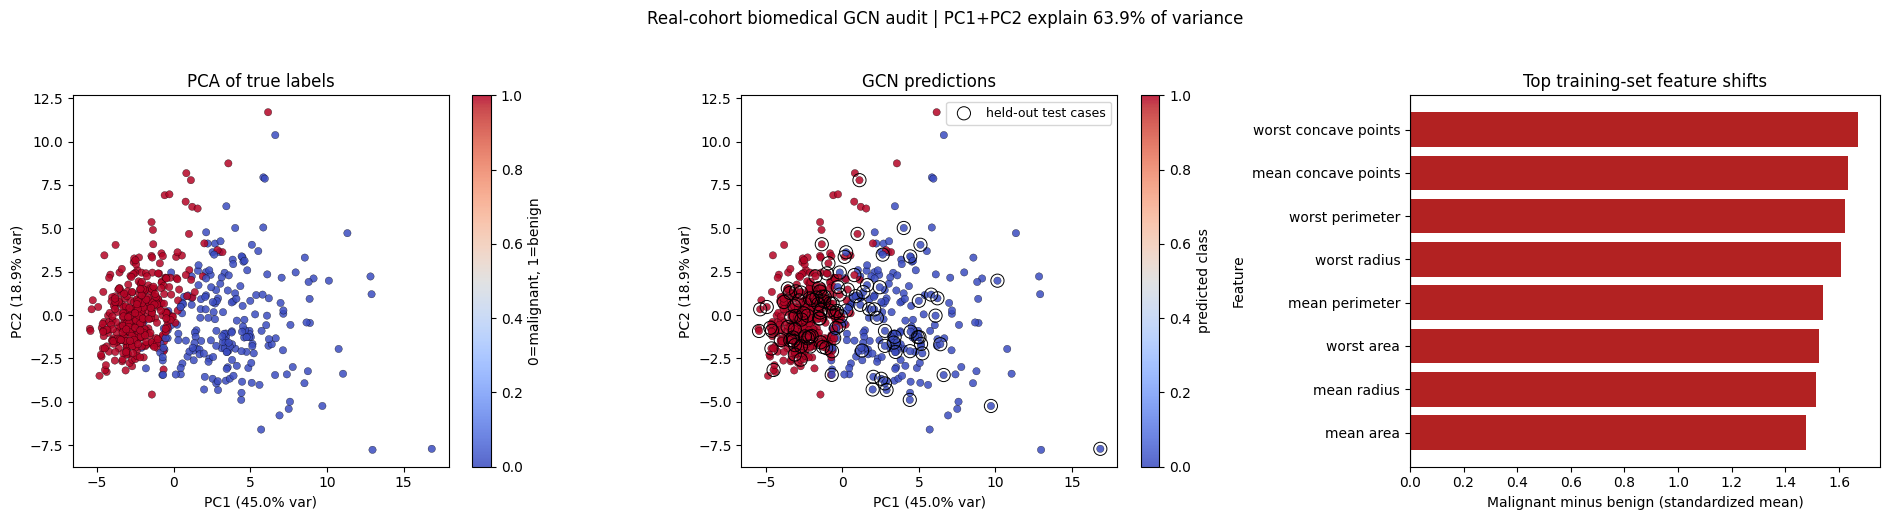

In [1]:
# Real-world biomedical GCN pipeline: provenance, leakage-aware preprocessing, and training

import os
import random
import sys
from pathlib import Path

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir():
            return candidate
    return current

proj_root = find_project_root()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 72)
print("Environment")
print("=" * 72)
print(f"Project root        : {proj_root}")
print(f"NumPy version       : {np.__version__}")
print(f"PyTorch version     : {torch.__version__}")
print(f"Execution device    : {device}")
print(f"Random seed         : {SEED}")

# ---------------------------------------------------------------------------
# SECTION A - Load the real WDBC cohort and create auditable raw tables
# ---------------------------------------------------------------------------
data = load_breast_cancer()
X_raw = data.data.astype(np.float32)
y = data.target.astype(np.int64)
feature_names = np.array(data.feature_names)
diagnosis_text = np.where(y == 0, "malignant", "benign")
case_ids = np.array([f"WDBC_{idx:03d}" for idx in range(len(y))])

raw_df = pd.DataFrame(X_raw, columns=feature_names)
raw_df.insert(0, "case_id", case_ids)
raw_df["diagnosis"] = diagnosis_text
raw_df["label"] = y

print("\n" + "=" * 72)
print("Dataset provenance and audit")
print("=" * 72)
print("Dataset            : Wisconsin Diagnostic Breast Cancer (WDBC)")
print("Source modality    : Digitised FNA biopsy image measurements")
print(f"Cases              : {len(y)}")
print(f"Features           : {X_raw.shape[1]}")
print(f"Malignant cases    : {(y == 0).sum()} ({(y == 0).mean() * 100:.1f}%)")
print(f"Benign cases       : {(y == 1).sum()} ({(y == 1).mean() * 100:.1f}%)")
print(f"Missing values      : {int(raw_df.isna().sum().sum())}")
print("First five features :", list(feature_names[:5]))

# ---------------------------------------------------------------------------
# SECTION B - Train/validation/test split before fitting the scaler
# ---------------------------------------------------------------------------
all_indices = np.arange(len(y))
train_pool_idx_np, test_idx_np = train_test_split(
    all_indices, test_size=0.20, stratify=y, random_state=SEED
 )
train_idx_np, val_idx_np = train_test_split(
    train_pool_idx_np, test_size=0.15, stratify=y[train_pool_idx_np], random_state=SEED
 )

scaler = StandardScaler()
scaler.fit(X_raw[train_idx_np])
X_std = scaler.transform(X_raw).astype(np.float32)

split_labels = np.full(len(y), "train", dtype=object)
split_labels[val_idx_np] = "validation"
split_labels[test_idx_np] = "test"

processed_df = pd.DataFrame(X_std, columns=feature_names)
processed_df.insert(0, "case_id", case_ids)
processed_df["diagnosis"] = diagnosis_text
processed_df["label"] = y
processed_df["split"] = split_labels

outputs_dir = proj_root / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)
raw_df.to_csv(outputs_dir / "breast_cancer_raw.csv", index=False)
processed_df.to_csv(outputs_dir / "breast_cancer_processed.csv", index=False)

print("\n" + "=" * 72)
print("Split design and preprocessing")
print("=" * 72)
print(f"Train samples       : {len(train_idx_np)}")
print(f"Validation samples  : {len(val_idx_np)}")
print(f"Test samples        : {len(test_idx_np)}")
print(f"Train mean after scaling : {X_std[train_idx_np].mean():.4f}")
print(f"Train std after scaling  : {X_std[train_idx_np].std():.4f}")
print(f"Saved raw cohort     -> {outputs_dir / 'breast_cancer_raw.csv'}")
print(f"Saved processed cohort -> {outputs_dir / 'breast_cancer_processed.csv'}")

# ---------------------------------------------------------------------------
# SECTION C - Feature audit: which measurements separate the classes most?
# ---------------------------------------------------------------------------
train_malignant = X_std[train_idx_np][y[train_idx_np] == 0]
train_benign = X_std[train_idx_np][y[train_idx_np] == 1]
mean_gap = train_malignant.mean(axis=0) - train_benign.mean(axis=0)
top_feature_idx = np.argsort(np.abs(mean_gap))[-8:][::-1]
feature_gap_df = pd.DataFrame(
    {
        "feature": feature_names[top_feature_idx],
        "malignant_minus_benign": mean_gap[top_feature_idx],
    }
 )

print("\nTop feature shifts in the training cohort:")
for row in feature_gap_df.itertuples(index=False):
    direction = "higher in malignant" if row.malignant_minus_benign > 0 else "higher in benign"
    print(f"  {row.feature:25s} {row.malignant_minus_benign:+.3f} ({direction})")

# ---------------------------------------------------------------------------
# SECTION D - Build the patient-similarity graph over the full cohort
# ---------------------------------------------------------------------------
k_neighbors = 7
A_sparse = kneighbors_graph(
    X_std, n_neighbors=k_neighbors, mode="connectivity", include_self=False
 )
A = A_sparse.maximum(A_sparse.T).toarray().astype(np.float32)
A += np.eye(A.shape[0], dtype=np.float32)

degree = A.sum(axis=1)
degree_inv_sqrt = 1.0 / np.sqrt(np.clip(degree, 1.0, None))
A_norm = degree_inv_sqrt[:, None] * A * degree_inv_sqrt[None, :]

n_edges = int((A.sum() - A.shape[0]) / 2)
avg_degree = float((A.sum(axis=1) - 1).mean())
graph_density = n_edges / (len(y) * (len(y) - 1) / 2)

print("\n" + "=" * 72)
print("Graph construction")
print("=" * 72)
print(f"k-nearest neighbors : {k_neighbors}")
print(f"Nodes               : {A.shape[0]}")
print(f"Edges               : {n_edges}")
print(f"Average degree      : {avg_degree:.2f}")
print(f"Graph density       : {graph_density * 100:.2f}%")

Xt = torch.tensor(X_std, dtype=torch.float32, device=device)
At = torch.tensor(A_norm, dtype=torch.float32, device=device)
yt = torch.tensor(y, dtype=torch.long, device=device)
train_idx = torch.tensor(train_idx_np, dtype=torch.long, device=device)
val_idx = torch.tensor(val_idx_np, dtype=torch.long, device=device)
test_idx = torch.tensor(test_idx_np, dtype=torch.long, device=device)

# ---------------------------------------------------------------------------
# SECTION E - Two-layer GCN with dropout and weighted cross-entropy
# ---------------------------------------------------------------------------
class ClinicalGCN(nn.Module):
    def __init__(self, in_features: int, hidden_dim: int, num_classes: int, dropout: float = 0.20):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_dim, bias=False)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2, bias=False)
        self.classifier = nn.Linear(hidden_dim // 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        h = adj @ x
        h = F.relu(self.fc1(h))
        h = self.dropout(h)
        h = adj @ h
        h = F.relu(self.fc2(h))
        h = self.dropout(h)
        return self.classifier(h)

model = ClinicalGCN(in_features=Xt.shape[1], hidden_dim=64, num_classes=2).to(device)
train_class_counts = np.bincount(y[train_idx_np], minlength=2)
class_weights = train_class_counts.sum() / (len(train_class_counts) * np.maximum(train_class_counts, 1))
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32, device=device)
 )
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)
n_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

print("\n" + "=" * 72)
print("Model and optimization")
print("=" * 72)
print(model)
print(f"Trainable parameters: {n_params}")
print(f"Class weights        : malignant={class_weights[0]:.3f}, benign={class_weights[1]:.3f}")

# ---------------------------------------------------------------------------
# SECTION F - Training loop with validation monitoring and checkpointing
# ---------------------------------------------------------------------------
epochs = 120
patience = 20
best_val_loss = float("inf")
best_state = None
wait = 0
history = {"epoch": [], "loss": [], "train_acc": [], "val_acc": [], "val_loss": []}

print("\nTraining progress")
print("-" * 72)
for epoch in range(1, epochs + 1):
    model.train()
    logits = model(Xt, At)
    loss = criterion(logits[train_idx], yt[train_idx])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        eval_logits = model(Xt, At)
        val_loss = criterion(eval_logits[val_idx], yt[val_idx]).item()
        preds = eval_logits.argmax(dim=1)
        train_acc = (preds[train_idx] == yt[train_idx]).float().mean().item()
        val_acc = (preds[val_idx] == yt[val_idx]).float().mean().item()

    history["epoch"].append(epoch)
    history["loss"].append(loss.item())
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | loss={loss.item():.4f} | "
            f"train_acc={train_acc:.3f} | val_acc={val_acc:.3f} | val_loss={val_loss:.4f}"
        )

    if wait >= patience:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    final_logits = model(Xt, At)
    final_probs = torch.softmax(final_logits, dim=1).cpu().numpy()
    final_preds = final_probs.argmax(axis=1)

test_accuracy = (final_preds[test_idx_np] == y[test_idx_np]).mean()
test_balanced_accuracy = balanced_accuracy_score(y[test_idx_np], final_preds[test_idx_np])

print("\n" + "=" * 72)
print("Held-out test summary")
print("=" * 72)
print(f"Test accuracy          : {test_accuracy:.4f} ({test_accuracy * 100:.1f}%)")
print(f"Balanced accuracy      : {test_balanced_accuracy:.4f}")
print("Interpretation         : balanced accuracy gives equal weight to malignant and benign recall.")

# ---------------------------------------------------------------------------
# SECTION G - PCA view plus descriptive feature separation
# ---------------------------------------------------------------------------
pca = PCA(n_components=2)
Z = pca.fit_transform(X_std)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

scatter_true = axes[0].scatter(
    Z[:, 0],
    Z[:, 1],
    c=y,
    cmap="coolwarm",
    s=28,
    alpha=0.85,
    edgecolors="k",
    linewidths=0.25,
 )
axes[0].set_title("PCA of true labels", fontsize=12)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
plt.colorbar(scatter_true, ax=axes[0], label="0=malignant, 1=benign")

scatter_pred = axes[1].scatter(
    Z[:, 0],
    Z[:, 1],
    c=final_preds,
    cmap="coolwarm",
    s=28,
    alpha=0.85,
    edgecolors="k",
    linewidths=0.25,
 )
axes[1].scatter(
    Z[test_idx_np, 0],
    Z[test_idx_np, 1],
    facecolors="none",
    edgecolors="black",
    s=90,
    linewidths=0.7,
    label="held-out test cases",
 )
axes[1].set_title("GCN predictions", fontsize=12)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
axes[1].legend(loc="best", fontsize=9)
plt.colorbar(scatter_pred, ax=axes[1], label="predicted class")

bar_colors = ["#b22222" if value > 0 else "#1f77b4" for value in feature_gap_df["malignant_minus_benign"]]
axes[2].barh(
    feature_gap_df["feature"][::-1],
    feature_gap_df["malignant_minus_benign"][::-1],
    color=bar_colors[::-1],
 )
axes[2].axvline(0.0, color="black", linewidth=0.8)
axes[2].set_title("Top training-set feature shifts", fontsize=12)
axes[2].set_xlabel("Malignant minus benign (standardized mean)")
axes[2].set_ylabel("Feature")

plt.suptitle(
    f"Real-cohort biomedical GCN audit | PC1+PC2 explain {pca.explained_variance_ratio_[:2].sum() * 100:.1f}% of variance",
    y=1.03,
 )
plt.tight_layout()
plt.show()

### Understanding the Training Dynamics

The revised pipeline uses **three partitions**: train, validation, and test.

- **Train split:** used to update model weights
- **Validation split:** used to monitor generalization during training and choose the best checkpoint
- **Test split:** used once at the end for the final report

That separation is a hallmark of reliable experimental design. If the test set influences model selection, the final score becomes optimistic.

### Why the loss is class-aware

The dataset is imbalanced: benign cases are more common than malignant cases. In medicine, that matters because a missed malignant case is usually more costly than an unnecessary follow-up on a benign case.

The notebook therefore uses **weighted cross-entropy**, which increases the penalty on underrepresented classes based on the training split.

$$\mathcal{L} = -\frac{1}{|\mathcal{V}_{\rm train}|} \sum_{i \in \mathcal{V}_{\rm train}} w_{y_i}\, \log \hat{p}_{i, y_i}$$

where $w_{y_i}$ is the class weight for sample $i$.

### Why early stopping and validation matter

Training for more epochs is not automatically better. After a point, the model may start fitting idiosyncrasies of the training set rather than signal that generalizes.

Validation monitoring helps answer a practical question:

**"At what point does additional training stop helping on unseen data?"**

### Interpreting the PCA and feature-shift plots

- **PCA view:** compresses 30 biomedical variables into a 2D map so humans can inspect class structure.
- **Prediction view:** shows whether the learned boundary follows the underlying geometry.
- **Feature-shift plot:** highlights which measurements separate malignant from benign cases most strongly in the training data. This is not causal biology, but it is a useful descriptive audit of the cohort.

For nontechnical readers, the message is simple: the notebook does not just produce a score. It also produces interpretable evidence about what the cohort looks like and where the model may struggle.

## 5. PCA Visualisation - Deep Dive

### Plain-English summary first

PCA is a tool for turning high-dimensional data into a 2D picture.

In this notebook, each patient has 30 features, which is too many dimensions to draw directly. PCA compresses those 30 numbers into two new coordinates that preserve as much variation as possible. That gives us a plot that humans can inspect.

Important limitation: PCA is mainly for **visual understanding** here. The GCN itself still learns from the full feature set, not just the 2D projection.

### Principal Component Analysis (PCA) Theory

PCA finds the orthonormal directions of maximum variance in the data. Given a centred data matrix $\bar{\mathbf{X}} \in \mathbb{R}^{n \times d}$:

1. Compute covariance matrix: $\boldsymbol{\Sigma} = \frac{1}{n}\bar{\mathbf{X}}^\top\bar{\mathbf{X}} \in \mathbb{R}^{d \times d}$
2. Eigendecompose: $\boldsymbol{\Sigma} = \mathbf{U}\boldsymbol{\Lambda}\mathbf{U}^\top$ where $\lambda_1 \geq \lambda_2 \geq \ldots$
3. Project: $\mathbf{Z} = \bar{\mathbf{X}}\,\mathbf{U}_{:,1:2} \in \mathbb{R}^{n \times 2}$

The fraction of variance preserved by the first $k$ components is:

$$\text{EVR}_k = \frac{\sum_{i=1}^k \lambda_i}{\sum_{i=1}^d \lambda_i}$$

For WDBC, PC1+PC2 typically explain **approximately 63-67%** of variance.

### Interpretation

| Scatter pattern | Meaning |
|----------------|---------|
| Two distinct clusters | Classes are linearly separable in feature space |
| Overlapping clouds | Require non-linear boundary; GCN's graph structure helps |
| One compact, one spread | One class is more heterogeneous |

### What the Two Plots Show

- **Left (true labels):** Ground-truth class structure after PCA projection. This reveals the intrinsic separability of the biomedical data.
- **Right (GCN predictions):** The GCN's decision in the same 2D space. Points where the colours *disagree* between the two plots are model errors.

**Clinical implication:** Misclassified malignant cases (false negatives) are more dangerous than false positives - the GCN's recall on the malignant class is the primary performance metric in a clinical context.

## 6. Detailed Evaluation — Confusion Matrix, ROC, and Clinical Trade-offs <a name="evaluation"></a>

The final code cell measures how strong the model is on **held-out test patients**. The most important change in this notebook is that we treat **malignant detection** as the clinically important positive class when we compute recall, ROC, and related summary statistics.

The cell below computes:
- a **confusion matrix** to show exactly where predictions are correct or wrong
- a **classification report** with precision, recall, and F1-score per class
- an **ROC curve** using malignant probability as the positive-class score
- a compact training-history plot so we can check whether optimization behaved sensibly

### Key Metrics Explained

$$\text{Precision} = \frac{TP}{TP + FP}, \qquad \text{Recall} = \frac{TP}{TP + FN}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}, \qquad \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

### Clinical Significance of Each Error Type

| Error | Definition | Clinical Impact |
|-------|------------|----------------|
| False Negative (FN) | Malignant predicted as benign | **Most serious** — a dangerous missed cancer case |
| False Positive (FP) | Benign predicted as malignant | Extra follow-up, anxiety, and possibly unnecessary procedures |

For that reason, this notebook emphasizes **malignant recall** and **malignant ROC behavior**, not only overall accuracy.

### What technical reviewers should notice

- The test split is untouched during training and model selection.
- The ROC curve is based on the malignant-class probability, which aligns the metric with the stated clinical objective.
- The summary statistics explicitly separate sensitivity, specificity, positive predictive value, and negative predictive value.

### What nontechnical readers should notice

A strong model is not just one that is correct often. It is one that makes the **right kind of mistakes as rarely as possible**, especially when one error type is much riskier than the other.

## 6A. Evaluation Primer for First-Time Readers

The final code cell is the quality-control stage of the notebook. It asks a simple question in plain language:

**If this model sees patients whose labels were hidden during training, how safely and how accurately does it behave?**

### Confusion matrix in plain language

A confusion matrix counts four kinds of outcomes.

| Reality | Prediction | Name |
|---------|------------|------|
| Malignant | Malignant | True Positive (TP) |
| Benign | Benign | True Negative (TN) |
| Benign | Malignant | False Positive (FP) |
| Malignant | Benign | False Negative (FN) |

For this notebook, we treat **malignant** as the positive class because that is the clinically riskier condition to miss.

### How to read the common metrics

| Metric | Question it answers |
|--------|---------------------|
| Accuracy | "How many predictions were correct overall?" |
| Precision | "When the model predicts malignant, how often is it right?" |
| Recall | "Of all truly malignant cases, how many did the model catch?" |
| Specificity | "Of all truly benign cases, how many did the model correctly dismiss?" |
| F1-score | "How well does the model balance precision and recall?" |

### ROC curve intuition

A model does not only output hard class labels. It also outputs class probabilities. The ROC curve shows what happens as we move the threshold used to call a case malignant.

If we lower the threshold:
- we usually catch more malignant cases
- but we may also create more false alarms

That trade-off is why ROC is useful in high-stakes diagnostics.

### How to read the output of the final cell

Read it in this order:
1. The classification report gives per-class precision, recall, and F1-score.
2. The confusion matrix shows exactly which mistakes happened.
3. The ROC curve shows malignant detection quality across thresholds.
4. The training-history plot checks whether optimization was stable rather than accidental.

For nontechnical readers, the one-sentence takeaway is:

**A good medical model is not only accurate; it is especially careful about not missing the dangerous cases.**

Held-out test evaluation
Test set size        : 114
Malignant test cases : 42
Benign test cases    : 72

Classification report
              precision    recall  f1-score   support

   malignant     0.8667    0.9286    0.8966        42
      benign     0.9565    0.9167    0.9362        72

    accuracy                         0.9211       114
   macro avg     0.9116    0.9226    0.9164       114
weighted avg     0.9234    0.9211    0.9216       114



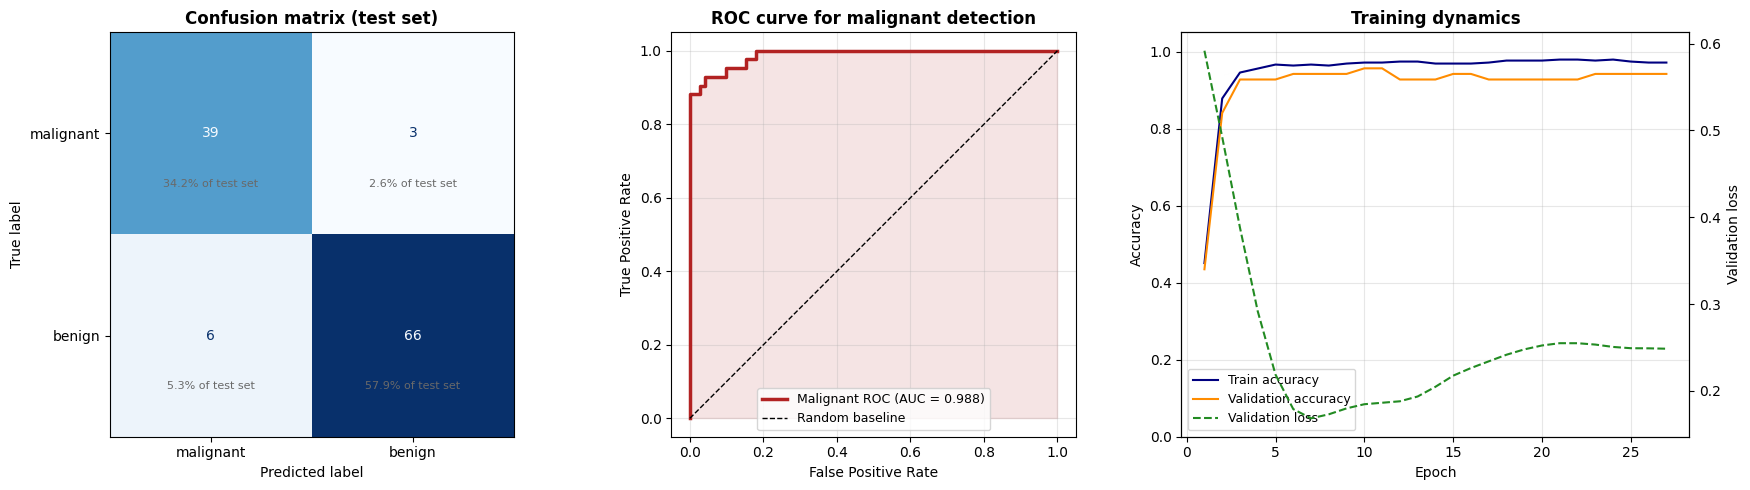


Summary metrics (malignant treated as positive class)
  Accuracy                 : 0.9211 (92.1%)
  Malignant recall         : 0.9286 (92.9%)
  Benign specificity       : 0.9167 (91.7%)
  Malignant precision      : 0.8667 (86.7%)
  Negative predictive value: 0.9565 (95.7%)
  Balanced accuracy        : 0.9226
  ROC AUC (malignant)      : 0.9881
  False negatives          : 3
  False positives          : 6


In [2]:
# Detailed evaluation: confusion matrix, malignant ROC, and training diagnostics
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
 )

model.eval()
with torch.no_grad():
    logits = model(Xt, At)
    probs = F.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(axis=1)

test_idx_np = test_idx.detach().cpu().numpy()
y_true_test = y[test_idx_np]
y_pred_test = preds[test_idx_np]

# For clinical evaluation we treat malignant (label 0) as the positive class.
y_true_malignant = (y_true_test == 0).astype(int)
y_pred_malignant = (y_pred_test == 0).astype(int)
y_prob_malignant = probs[test_idx_np, 0]

print("=" * 60)
print("Held-out test evaluation")
print("=" * 60)
print(f"Test set size        : {len(y_true_test)}")
print(f"Malignant test cases : {(y_true_test == 0).sum()}")
print(f"Benign test cases    : {(y_true_test == 1).sum()}")

print("\n" + "=" * 60)
print("Classification report")
print("=" * 60)
print(
    classification_report(
        y_true_test,
        y_pred_test,
        labels=[0, 1],
        target_names=data.target_names,
        digits=4,
    )
 )

cm = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
tp = cm[0, 0]
fn = cm[0, 1]
fp = cm[1, 0]
tn = cm[1, 1]

malignant_recall = tp / max(tp + fn, 1)
malignant_specificity = tn / max(tn + fp, 1)
malignant_precision = tp / max(tp + fp, 1)
negative_predictive_value = tn / max(tn + fn, 1)
overall_accuracy = (tp + tn) / max(cm.sum(), 1)
balanced_accuracy = 0.5 * (malignant_recall + malignant_specificity)

fpr, tpr, _ = roc_curve(y_true_malignant, y_prob_malignant)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["malignant", "benign"],
 )
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix (test set)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

total = cm.sum()
for row in range(2):
    for col in range(2):
        axes[0].text(
            col,
            row + 0.25,
            f"{cm[row, col] / total * 100:.1f}% of test set",
            ha="center",
            va="center",
            color="dimgray",
            fontsize=8,
        )

axes[1].plot(fpr, tpr, lw=2.5, color="firebrick", label=f"Malignant ROC (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
axes[1].fill_between(fpr, tpr, alpha=0.12, color="firebrick")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curve for malignant detection", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect("equal")

axes[2].plot(history["epoch"], history["train_acc"], color="navy", label="Train accuracy")
axes[2].plot(history["epoch"], history["val_acc"], color="darkorange", label="Validation accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0.0, 1.05)
axes[2].set_title("Training dynamics", fontsize=12, fontweight="bold")
axes[2].grid(True, alpha=0.3)
loss_axis = axes[2].twinx()
loss_axis.plot(history["epoch"], history["val_loss"], color="forestgreen", linestyle="--", label="Validation loss")
loss_axis.set_ylabel("Validation loss")
train_lines, train_labels = axes[2].get_legend_handles_labels()
loss_lines, loss_labels = loss_axis.get_legend_handles_labels()
axes[2].legend(train_lines + loss_lines, train_labels + loss_labels, loc="best", fontsize=9)

plt.tight_layout()
plt.show()

print("\nSummary metrics (malignant treated as positive class)")
print(f"  Accuracy                 : {overall_accuracy:.4f} ({overall_accuracy * 100:.1f}%)")
print(f"  Malignant recall         : {malignant_recall:.4f} ({malignant_recall * 100:.1f}%)")
print(f"  Benign specificity       : {malignant_specificity:.4f} ({malignant_specificity * 100:.1f}%)")
print(f"  Malignant precision      : {malignant_precision:.4f} ({malignant_precision * 100:.1f}%)")
print(f"  Negative predictive value: {negative_predictive_value:.4f} ({negative_predictive_value * 100:.1f}%)")
print(f"  Balanced accuracy        : {balanced_accuracy:.4f}")
print(f"  ROC AUC (malignant)      : {roc_auc:.4f}")
print(f"  False negatives          : {fn}")
print(f"  False positives          : {fp}")

## 7. Applications & Extensions

### Real-World Biomedical GNN Use Cases

#### A. Multi-Omics Integration
Combine gene expression, DNA methylation, and protein levels by building **heterogeneous graphs** where different node types represent genes, proteins, and metabolites connected by biological pathway edges.

**Architecture:** Heterogeneous GNN (HAN, HGT) with separate message-passing per edge type.

#### B. Drug–Target Interaction (DTI)
Build a bipartite graph: drug nodes ↔ protein target nodes with known binding affinities as edge weights.  GCN predicts binding probability for unseen drug-protein pairs.

**Formula:** $\hat{y}_{dt} = \sigma(\mathbf{h}_d^\top \mathbf{W}\, \mathbf{h}_t)$ where $\mathbf{h}_d, \mathbf{h}_t$ are GNN embeddings.

#### C. Single-Cell RNA-seq Analysis
- Cells as nodes, edges by Leiden/Louvain clustering similarity
- GCN propagates gene expression, revealing developmental trajectories
- **UMAP/t-SNE** commonly used for visualisation (non-linear reduction, contrast with PCA)

#### D. Cancer Genomics Sub-type Discovery
Train GCN on TCGA gene expression data with protein interaction network as graph topology → identify novel molecular subtypes for precision oncology.

---

### Extending This Demo

#### 1. Feature-Level Attention (GAT)
Replace uniform aggregation $\frac{1}{d_i}$ with **learned attention weights**:

$$\alpha_{ij} = \frac{\exp(\text{LeakyReLU}(\mathbf{a}^\top[\mathbf{W}\mathbf{h}_i \| \mathbf{W}\mathbf{h}_j]))}{\sum_{k \in \mathcal{N}(i)}\exp(\text{LeakyReLU}(\mathbf{a}^\top[\mathbf{W}\mathbf{h}_i \| \mathbf{W}\mathbf{h}_k]))}$$

The attention weight $\alpha_{ij}$ learns which neighbours are most informative.

#### 2. Deeper GNNs and Over-smoothing
Adding more layers makes node representations converge to the same value (all neighbours look the same) — called **over-smoothing**.  Solutions:
- Residual connections: $\mathbf{H}^{(l+1)} = \sigma(\tilde{A}\mathbf{H}^{(l)}\mathbf{W}^{(l)}) + \mathbf{H}^{(l)}$
- Drop-edge: randomly mask edges during training
- Jumping Knowledge (JK) networks: concatenate representations from all layers

#### 3. Inductive Generalisation (GraphSAGE)
The current transductive GCN can only predict for nodes seen during training.  GraphSAGE uses a fixed-size neighbourhood sampler to train an *inductive* model that generalises to unseen patients at test time.

---

### Hyperparameter Sensitivity Guide

| Hyperparameter | Low value | High value | Recommended |
|----------------|-----------|-----------|-------------|
| $k$ (neighbours) | Sparse graph, may disconnect | Dense, class mixing | 7–15 |
| hidden dim | Underfitting | Overfitting | 32–128 |
| learning rate | Slow convergence | Unstable | 1e-3 with Adam |
| weight decay | No regularisation | Underfitting | 1e-4 |
| epochs | Underfitting | Overfitting | 50–200 with early stop |

---

### Connection to QAOA & the Hybrid Pipeline <a name="qaoa"></a>

The GCN trained here serves a dual role in the hybrid pipeline:

1. **Standalone classifier** for patient diagnosis (demonstrated here)
2. **Graph embedding network** whose learned representations can be fed to QAOA for **combinatorial sub-problems**, e.g.:
   - Selecting the optimal cohort of $k$ patients for a clinical trial (MaxCut-like partitioning)
   - Feature selection via graph cuts on the feature correlation graph
   - Multi-centre data aggregation (privacy-preserving graph partitioning)

The connection is that QAOA solves **combinatorial optimisation on graphs** — the same structural domain where GCNs excel at learning representations.  Together, the GNN produces compact node embeddings that QAOA can use as a warm-start for its variational parameters, dramatically reducing the parameter optimisation landscape.  See `qaoa_demo.ipynb` for the full technical treatment.

## 8. Summary & Key Takeaways

### What We Built

| Step | Output |
|------|--------|
| Load the full WDBC cohort | 569 real patient-derived benchmark cases with 30 biomedical features |
| Create train, validation, and test splits | Leakage-aware experimental design |
| Fit the scaler on training data only | Standardised feature matrix without test-set contamination |
| Save raw and processed cohort tables | Auditable CSV artifacts for inspection and reuse |
| Build a symmetric patient graph | $k$-NN similarity network over the full cohort |
| Train a two-layer GCN with class-aware loss | Graph-based classifier tuned for clinically relevant errors |
| Evaluate with confusion matrix and malignant ROC | Metrics aligned with medical risk, not just headline accuracy |

### What makes this notebook stronger than a toy demo

- It uses a **real biomedical dataset** rather than synthetic samples.
- It distinguishes **research realism** from true clinical deployment claims.
- It avoids a common evaluation mistake by fitting preprocessing on the training split only.
- It reports metrics in a way that reflects the cost of missing malignant cases.
- It leaves behind output artifacts that another reviewer can inspect, rerun, or extend.

### Technical takeaway

The notebook demonstrates a complete graph-ML workflow: feature standardisation, similarity-graph construction, normalized message passing, class-weighted optimization, validation-aware training, and clinically aligned evaluation. For a technical hiring manager, that signals more than model usage; it signals experimental discipline.

### Nontechnical takeaway

A simple way to describe the result is this: the notebook turns a table of real patient measurements into a map of similar patients, then trains a model that learns from both the patient and the surrounding neighborhood. The evaluation focuses on avoiding the most dangerous mistake in cancer screening: missing malignant cases.

### Relevance to hybrid AI and accelerated computing

The core computations in this notebook are matrix operations, tensor transforms, and graph-based message passing, which are exactly the kinds of workloads that scale well on modern accelerated hardware. That makes this biomedical notebook a credible companion to the repository's quantum-optimization work: it shows the same project can span scientific communication, graph ML, and performance-oriented AI engineering.

### Next Notebook

Proceed to **`qaoa_demo.ipynb`** to see how the Quantum Approximate Optimization Algorithm (QAOA) solves MaxCut instances, and how a GNN can help reduce per-instance optimization effort by learning graph-informed priors.